In [32]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn

plt.rcParams["font.family"] = "AppleGothic"

def clean_kosis_csv(path):
    df = pd.read_csv(path, encoding="cp949") # or "euc-kr"
    df = df.dropna(axis=1, how='all')
    df.columns = df.columns.map(
        lambda c: pd.to_datetime(c.replace(" 월", ""), format="%Y.%m").to_period("M").to_timestamp() #.strftime("%Y-%m")
        if pd.Series(c).str.match(r"^\d{4}\.\d{2}\s월$").item()
        else c
    )
    
    return df

def filter_kosis_data(df):
    property_type_mask = df['주택유형별'] == '아파트'
    
    regions_of_interest = ['전국', '수도권', '지방', '5대광역시', '8개도', '서울', '서초', '강남', '송파', '강동', '대구']
    regions_of_interest_mask = df['지역별'].isin(regions_of_interest)
    
    filtered_df = df[
        property_type_mask 
        #& regions_of_interest_mask
    ]
    filtered_df = filtered_df.drop(columns=['주택유형별', '항목']).set_index('지역별').T
    filtered_df = filtered_df.sort_index()
    
    return filtered_df

def clean_bok_csv(path="data/bok_base_rate.csv"):
    df = pd.read_csv(path)
    df = df.drop(columns=['통계표', '단위', '변환'])
    df = df.set_index('계정항목').T
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    return df

**출처:**
- 기준금리: https://ecos.bok.or.kr/#/SearchStat
- 전월세 전환율: https://kosis.kr/statHtml/statHtml.do?sso=ok&returnurl=https%3A%2F%2Fkosis.kr%3A443%2FstatHtml%2FstatHtml.do%3Fconn_path%3DI3%26tblId%3DDT_30404_N0006_R1%26orgId%3D408%26
- 전세가율: https://kosis.kr/statHtml/statHtml.do?sso=ok&returnurl=https%3A%2F%2Fkosis.kr%3A443%2FstatHtml%2FstatHtml.do%3Fconn_path%3DI3%26tblId%3DDT_30404_N0006_R1%26orgId%3D408%26
  

In [35]:
cap_rates = filter_kosis_data(
    clean_kosis_csv(path="data/korea_cap_rates.csv")
)

deposit_ratios = filter_kosis_data(
    clean_kosis_csv(path="data/korea_deposit_to_price_ratio.csv")
)

purchase_supply_demand = filter_kosis_data(
    clean_kosis_csv(path="data/purchase_supply_demand.csv")
)

deposit_supply_demand = filter_kosis_data(
    clean_kosis_csv(path="data/deposit_supply_demand.csv")
)

rent_supply_demand = filter_kosis_data(
    clean_kosis_csv(path="data/rent_supply_demand.csv")
)

bok_base_rate = clean_bok_csv(path="data/bok_base_rate.csv")
bok_base_rate['month'] = pd.to_datetime(bok_base_rate.index).to_period("M").to_timestamp() #.strftime("%Y-%m")
bok_base_rate_monthly = bok_base_rate.groupby(['month']).last()

In [37]:
cap_rates['대구']#.plot()

2011-01-01    7.600000
2011-02-01    7.600000
2011-03-01    7.600000
2011-04-01    7.600000
2011-05-01    7.600000
                ...   
2025-07-01    5.231154
2025-08-01    5.217391
2025-09-01    5.217391
2025-10-01    5.210029
2025-11-01    5.193717
Name: 대구, Length: 179, dtype: float64

In [39]:
deposit_ratios['대구']

2012-01-01    72.618665
2012-02-01    72.482702
2012-03-01    72.495482
2012-04-01    72.489712
2012-05-01    72.650409
                ...    
2025-08-01    69.252150
2025-09-01    69.428333
2025-10-01    69.601375
2025-11-01    69.782737
2025-12-01    69.928996
Name: 대구, Length: 168, dtype: float64

In [41]:
cap_rates.describe()

지역별,전국,수도권,지방,5대광역시,8개도,서울,강북권역,도심권,동북권,서북권,...,마산회원,진해,진주,통영,사천,김해,거제,양산,제주,제주
count,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,...,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000
mean,5.583954,5.359752,6.027549,5.458034,6.701316,4.968571,5.105800,5.131082,5.012070,4.856679,...,5.589926,5.637470,5.933331,6.913991,6.759550,5.863087,6.561731,5.917572,5.957541,5.890218
std,1.193872,1.210353,1.162899,0.956234,1.415281,1.096745,1.092664,1.020610,1.080968,1.042601,...,1.369717,0.768134,1.616003,1.399908,1.340737,1.158364,1.815475,1.123471,1.332084,1.271705
min,4.457143,4.263016,4.800000,4.400511,5.196850,3.946365,4.085918,4.061677,3.891892,3.750058,...,1.749132,4.731546,4.214812,4.800000,4.683880,4.446509,4.522974,4.556962,4.653158,4.444444
25%,4.682927,4.409964,5.217391,4.798722,5.654136,4.075214,4.216216,4.242774,4.137931,4.000000,...,4.949275,5.000000,4.890184,6.000000,5.766183,5.078248,5.048268,4.980216,4.784078,4.835592
50%,5.205786,4.991150,5.581395,5.239650,6.000000,4.615385,4.733219,4.908122,4.693631,4.600149,...,5.538462,5.333333,5.218773,6.604645,6.245000,5.414822,5.538462,5.531370,5.477190,5.263157
75%,6.350000,6.000000,6.900000,6.000000,7.650000,5.750000,5.850000,5.750000,5.750000,5.450000,...,6.800000,6.100000,7.150000,7.618918,8.000000,6.550000,8.400000,6.950000,7.200000,7.200000
max,8.400000,8.100000,8.800000,7.800000,10.000000,7.400000,7.500000,7.300000,7.300000,7.200000,...,8.000000,7.500000,10.300000,10.500000,10.300000,8.700000,9.800000,8.000000,9.100000,8.900000


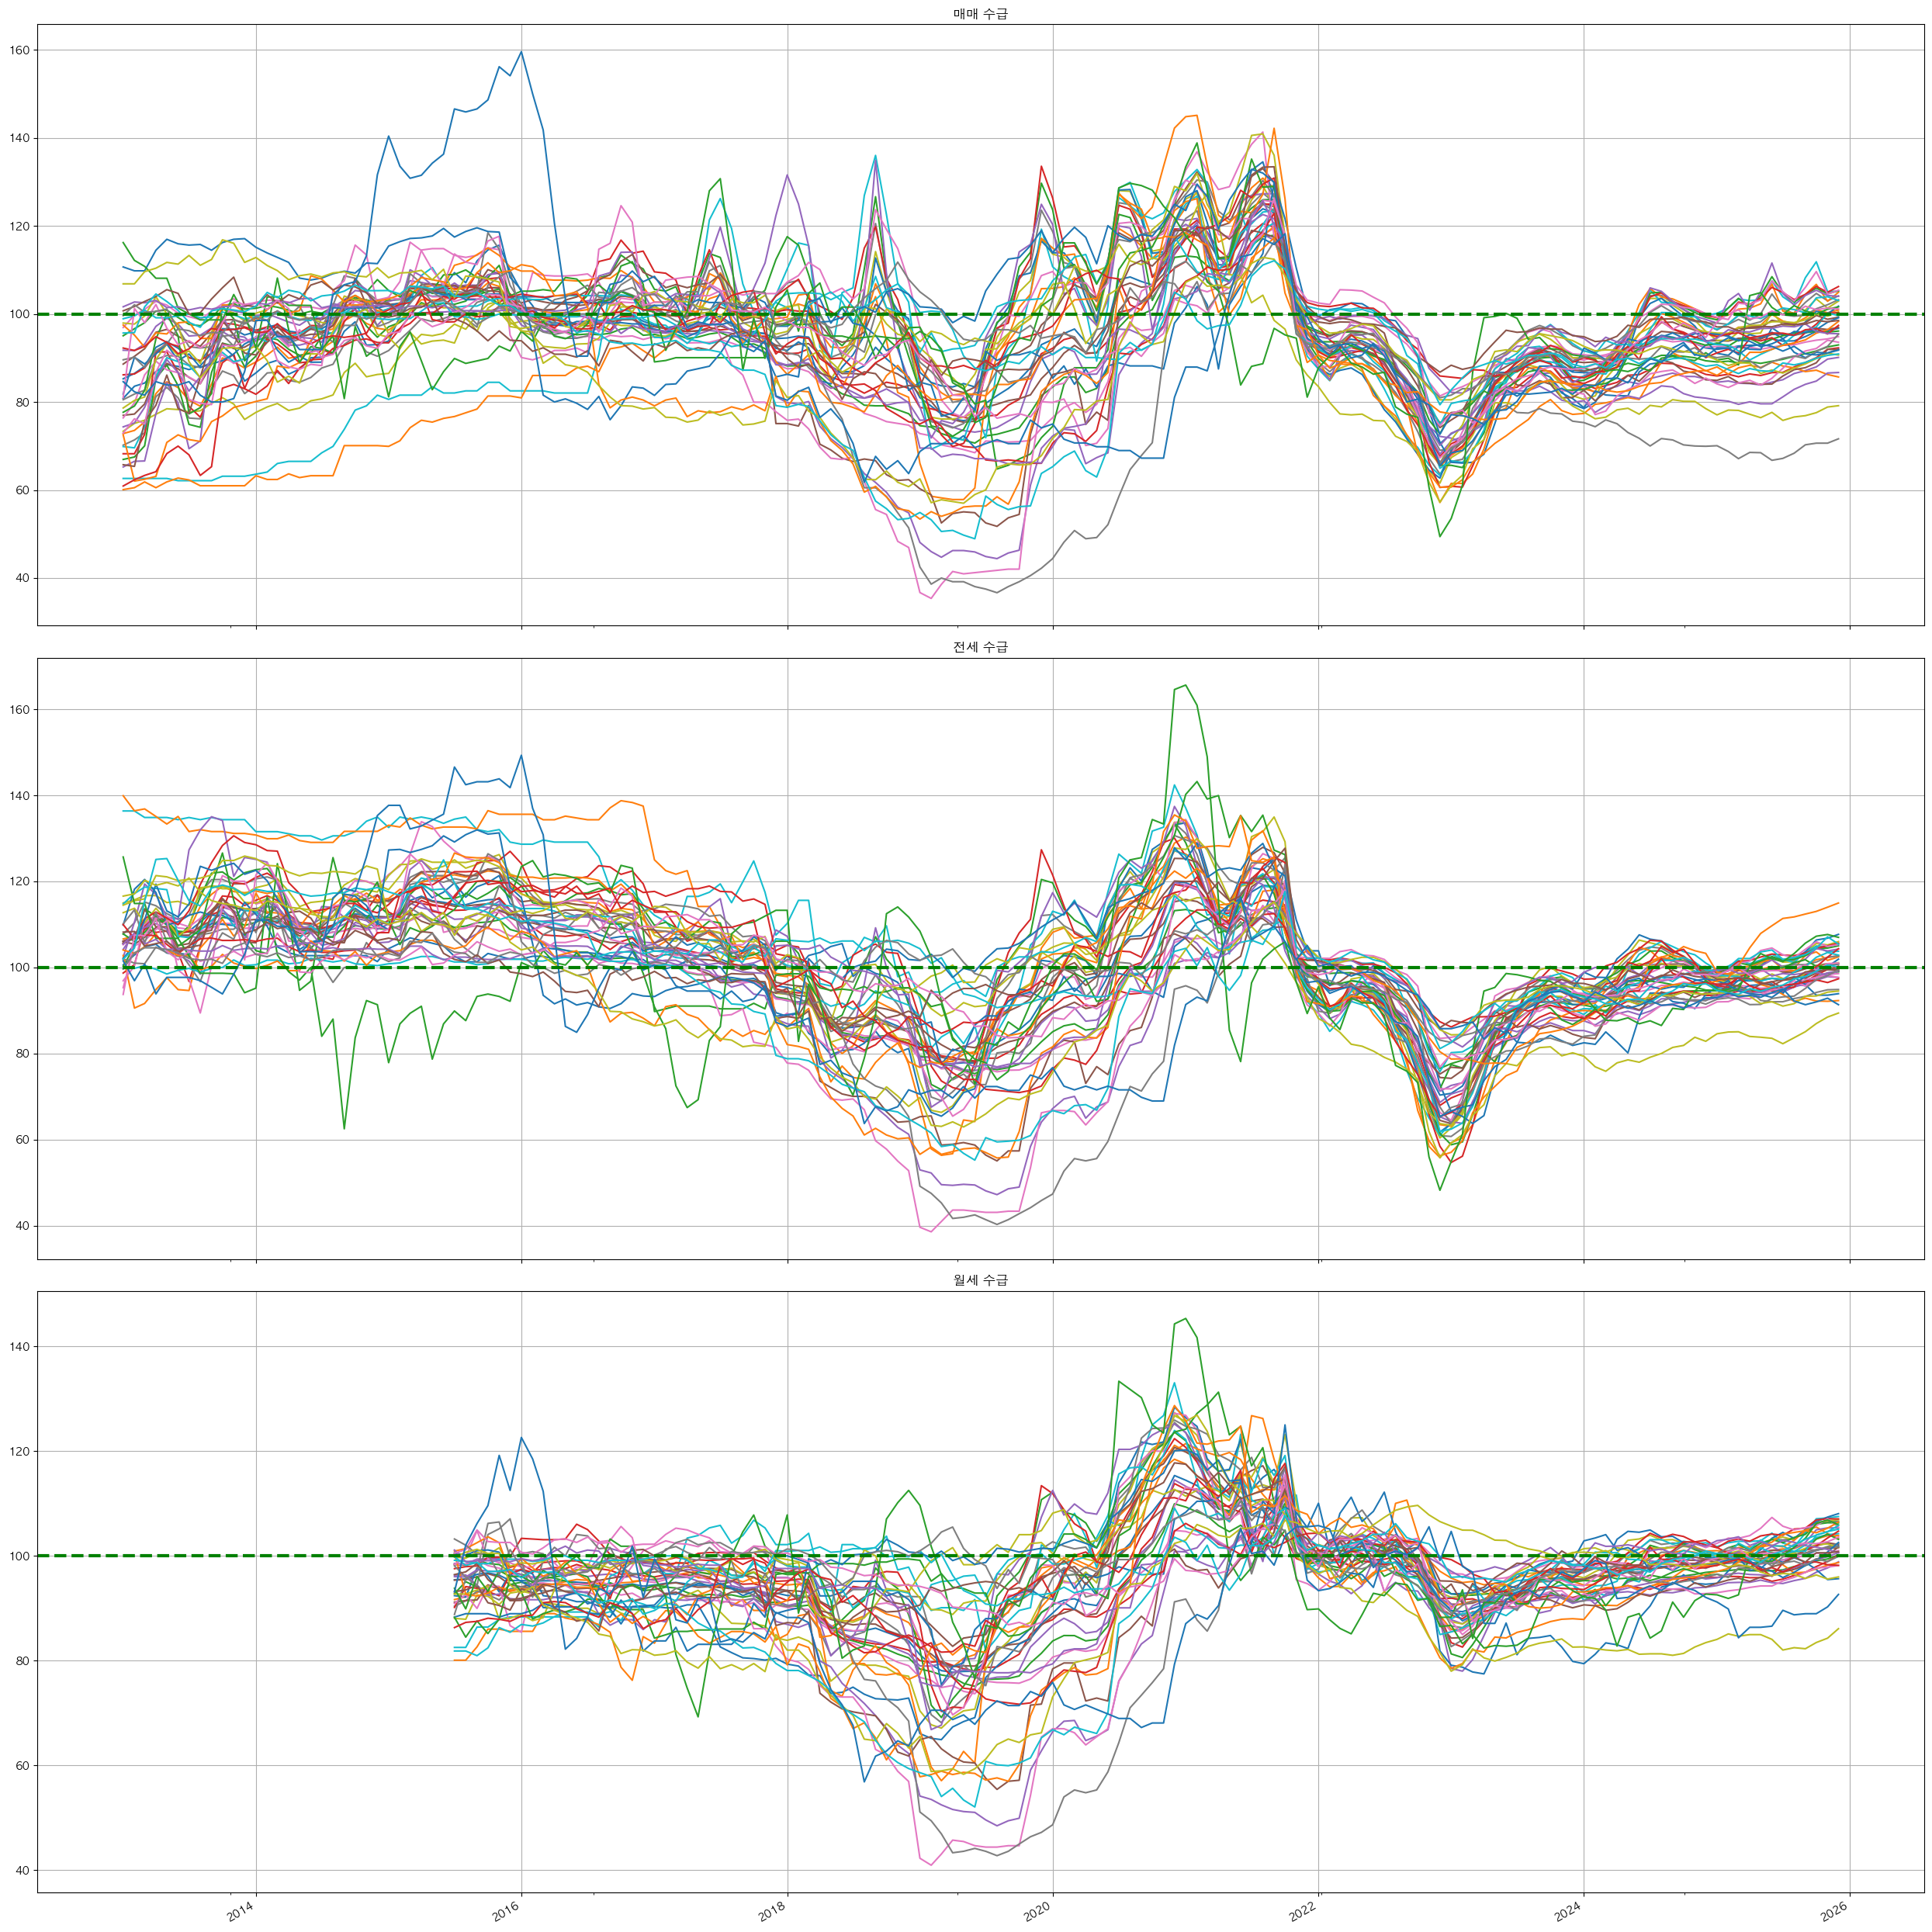

In [43]:
fig,ax = plt.subplots(3,1, figsize=(25,25), sharex=True)
purchase_supply_demand.plot(legend=False, ax=ax[0])
deposit_supply_demand.plot(legend=False, ax=ax[1])
rent_supply_demand.plot(legend=False, ax=ax[2])

ax[0].set_title('매매 수급')
ax[1].set_title('전세 수급')
ax[2].set_title('월세 수급')
for i in range(len(ax)):
    ax[i].grid()
    #ax[i].axhline(200, label='수요 우위', ls='--', c='red', lw=3)
    ax[i].axhline(100, label='수요 = 공급', ls='--', c='green', lw=3)
    #ax[i].axhline(0, label='공급 우위', ls='--', c='black', lw=3)

plt.tight_layout();
#bok_base_rate_monthly['한국은행 기준금리'].plot()

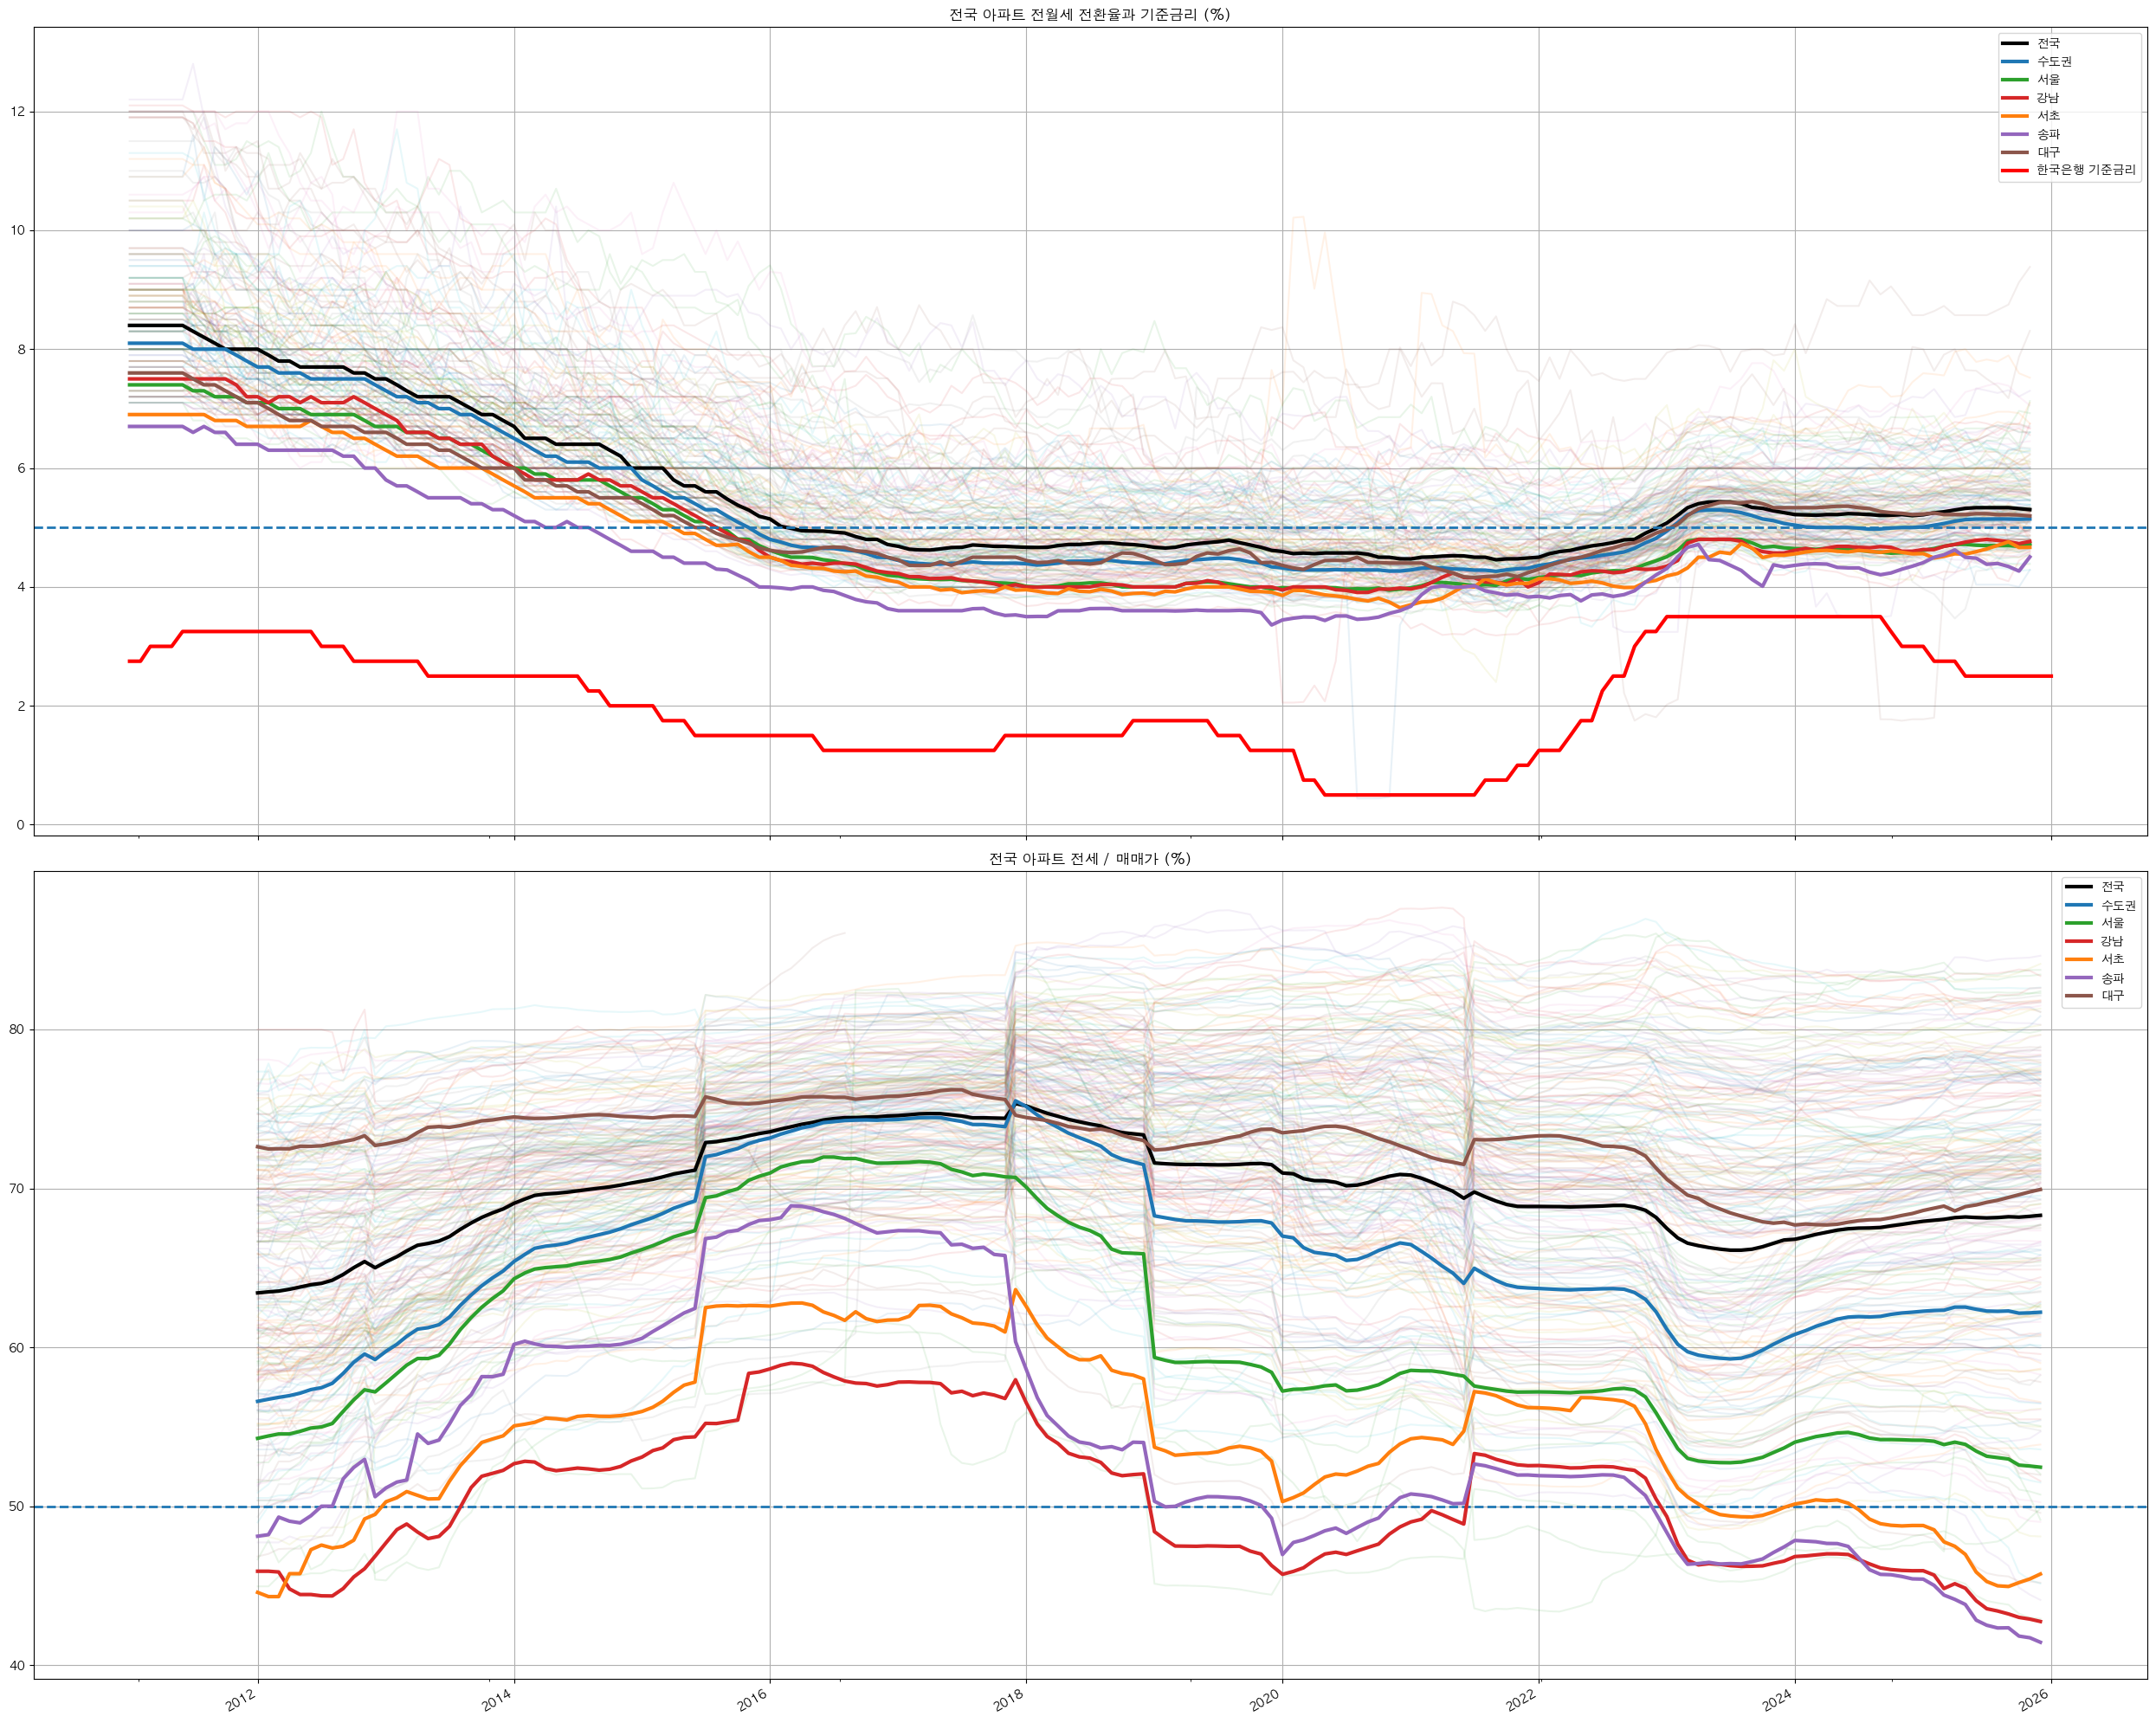

In [44]:
fig,ax = plt.subplots(2, 1, figsize=(25,20), sharex=True)

regions = ['전국', '수도권', '서울', '강남', '서초', '송파', '대구']
colors = {
    '전국': 'black',
    '수도권': 'tab:blue',
    '서울': 'tab:green',
    '강남': 'tab:red',
    '서초': 'tab:orange',
    '송파': 'tab:purple', 
    '대구': 'tab:brown',
}
alpha = 0.1

ax[0].set_title('전국 아파트 전월세 전환율과 기준금리 (%)')
cap_rates.plot(ax=ax[0], alpha=alpha, legend=False)

for r in regions:
    cap_rates[r].plot(ax=ax[0], lw=3, color=colors[r], label=r, legend=True)

bok_base_rate_monthly['한국은행 기준금리'].plot(
    ax=ax[0], lw=3, color='red', label='한국은행 기준금리', legend=True
)
ax[0].axhline(5, label='전월세 전환율 5% 기준선', ls='--', lw=2)

ax[1].set_title('전국 아파트 전세 / 매매가 (%)')
deposit_ratios.plot(ax=ax[1], alpha=alpha, legend=False)
ax[1].axhline(50, label='전세가율 40% 기준선', ls='--', lw=2)

for r in regions:
    deposit_ratios[r].plot(ax=ax[1], lw=3, color=colors[r], label=r, legend=True)

for i in range(len(ax)):
    ax[i].grid()

plt.tight_layout()

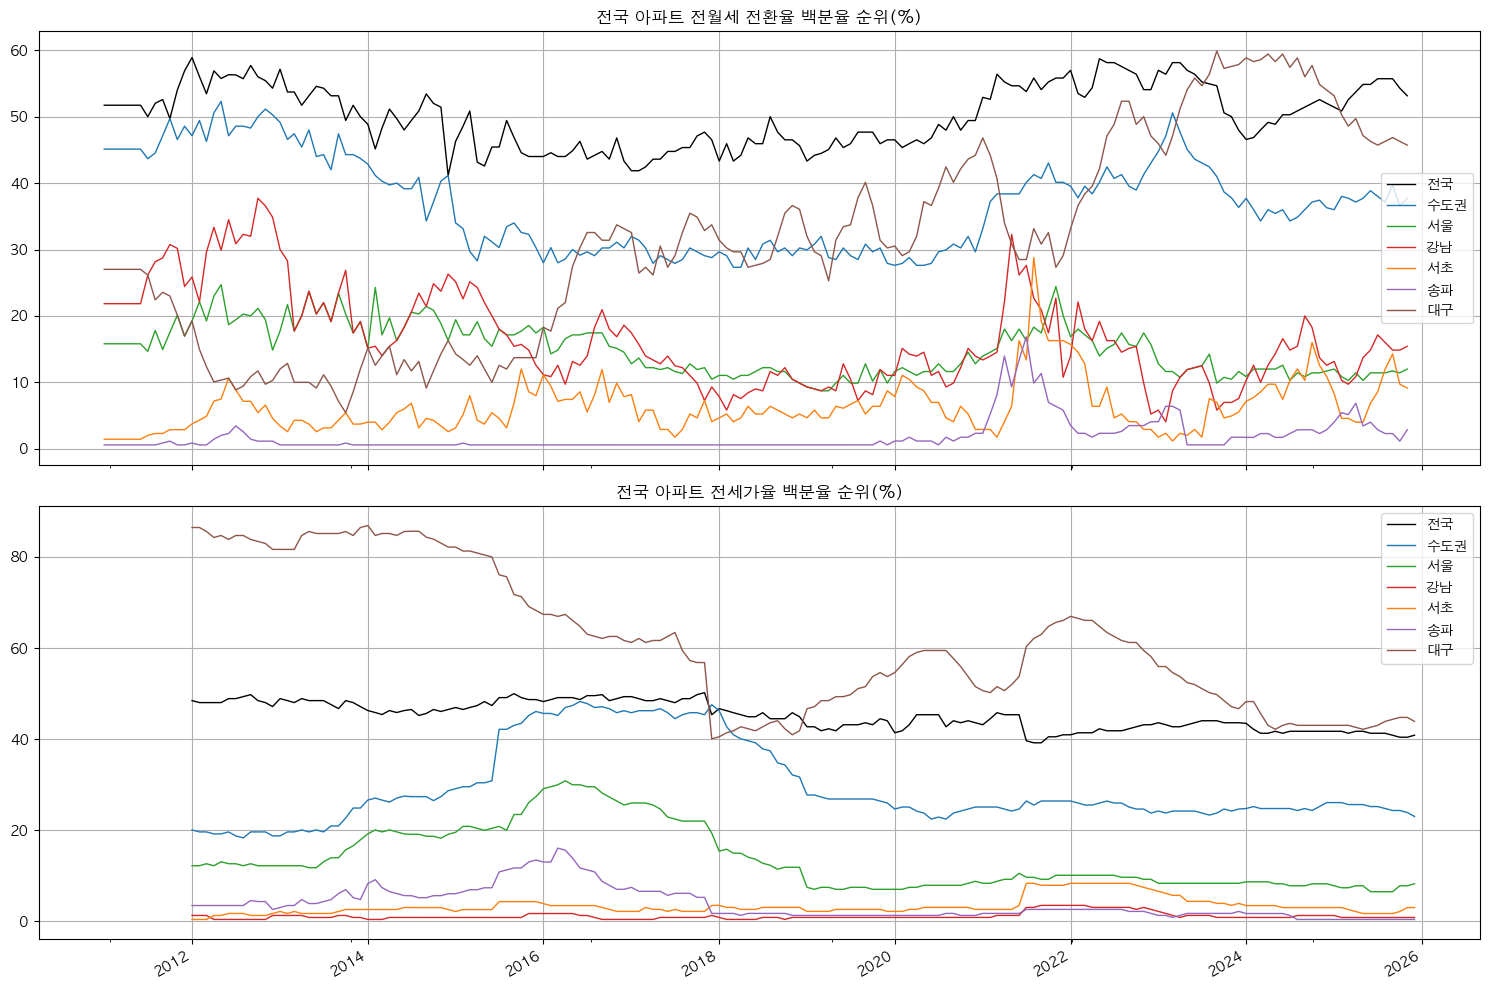

In [46]:
fig,ax = plt.subplots(2, 1, figsize=(15,10), sharex=True)

for r in regions:
    (cap_rates.rank(axis=1, pct=True) * 100)[r].plot(ax=ax[0], lw=1, color=colors[r], label=r, legend=True)

for r in regions:
    (deposit_ratios.rank(axis=1, pct=True) * 100)[r].plot(ax=ax[1], lw=1, color=colors[r], label=r, legend=True)

ax[0].set_title('전국 아파트 전월세 전환율 백분율 순위(%)')
ax[1].set_title('전국 아파트 전세가율 백분율 순위(%)')

for i in range(len(ax)):
    ax[i].grid()

plt.tight_layout()